- 시퀀스-투-시퀀스(Sequence-to-Sequence)는 입력된 시퀀스로부터 다른 도메인의 시퀀스를 출력
- 기본적으로 [RNN 아키텍처(LSTM/GRU)](../07.%20RNN/07-02.%20lstm_and_gru.ipynb)를 사용

# 1. 모델의 개요(Overview)
- seq2seq는 크게 두 개로 구성된 아키텍처로 구성
    - 인코더(RNN 아키텍쳐)
        - 입력 문장의 모든 단어들을 순차적으로 입력
        - 하나의 컨텍스트 벡터(마지막 셀의 은닉상태)를 출력
    - 디코더(RNN 아키텍쳐)
        - 컨텍스트 벡터를 활용(첫번째 셀의 은닉상태)
        - 시퀀스를 한 개씩 순차적으로 출력

# 2. 동작 과정
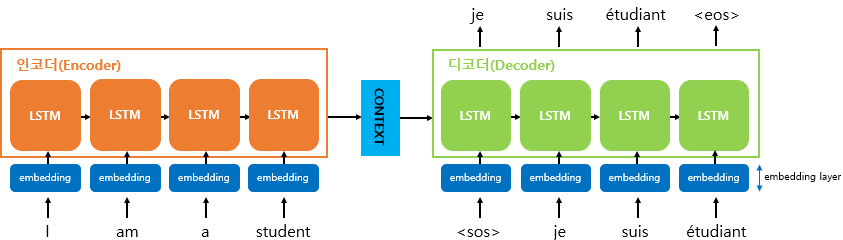
## 2.1 임베딩 층
- 주어진 단어는 모두 임베딩 층을 거쳐 RNN 셀에 입력됨
## 2.2 훈련 단계
- 디코더의 초기 입력으로 문장의 시작을 의미하는 심볼 `<sos>`가 입력
- 인코더의 컨텍스트 벡터와 함께 정답 시퀀스를 전달
- 컨텍스트 벡터를 은닉상태 입력으로 삼아 이번 은닉상태를 생성
    - 생성된 은닉상태는 밀집층과 소프트맥스 함수를 거쳐 사전에서 가장 확률 높은 단어를 출력
    - 출력된 단어<sup>[1](#교사_강요)</sup>와 생성된 은닉상태는 다음 RNN 셀에 전달
    - 은닉상태는 이전까지의 모든 RNN 셀의 정보를 담고 있으므로, 입출력 시퀀스를 표현함
- 두번째 시점의 디코더 RNN 셀은 다시 다음에 올 단어인 suis를 예측
- 예측된 결과를 정답 시퀀스의 내용과 비교하여 손실함수를 계산하고 학습
## 2.3 테스트 단계
- 정답 시퀀스가 제공되지 않음
- 위 과정을 문장의 끝을 의미하는 심볼인 `<eos>`가 다음 단어로 예측될 때까지 반복

---

<a name="교사_강요">1</a>: 교사 강요 기법을 사용시, 입력으로 이전 디코더 셀의 출력이 아닌 정답 레이블의 해당값을 입력으로 삼는다. 이는 이전 디코더 셀이 생성한 오답이 이후 디코더 셀의 입력으로 사용되어 연속적으로 오답을 생성하여 훈련이 어려워지는 것을 막기 위함이다.